In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 200
x = np.random.uniform(-np.pi, np.pi, size=N)
X = x.reshape(-1, 1)
y = (np.tanh(x**2 + x - 1))**5 + np.random.normal(scale=0.08, size=N)


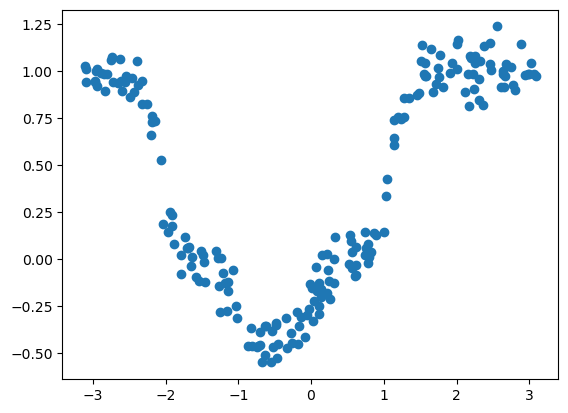

In [3]:
plt.scatter(X,y)

In [4]:
def tanh(x):
    return np.tanh(x)

def dtanh(a):
    return 1 - a**2

In [5]:
def init_network(layer_dims, activation="tanh"):
    params = {}
    for i in range(1, len(layer_dims)):
        input_dim = layer_dims[i - 1]
        output_dim = layer_dims[i]
        params[f"W{i}"] = np.random.randn(output_dim, input_dim) * np.sqrt(1.0 / input_dim)
        params[f"b{i}"] = np.zeros(output_dim)
    params["activation"] = activation
    return params

In [6]:

def forward(X, params):
    activation_fn = tanh
    cache = {"A0": X}

    A = X
    L = len([k for k in params if k.startswith("W")]) 

    for l in range(1, L + 1):
        W, b = params[f"W{l}"], params[f"b{l}"]
        Z = A.dot(W.T) + b
        if l < L:  
            A = activation_fn(Z)
        else:      
            A = Z
        cache[f"Z{l}"], cache[f"A{l}"] = Z, A

    y_pred = A.ravel()
    return y_pred, cache

In [7]:

def backward(y_pred, y_true, params, cache):
    L = len([k for k in params if k.startswith("W")])
    grads = {}
    N = y_true.shape[0]

    dA = (2.0 / N) * (y_pred - y_true).reshape(N, 1)

    for l in range(L, 0, -1):
        A_prev = cache[f"A{l-1}"]
        Z = cache[f"Z{l}"]
        W = params[f"W{l}"]

        if l == L:
            dZ = dA  
        else:
            act_fn = dtanh
            dZ = dA * act_fn(cache[f"A{l}"])

        grads[f"dW{l}"] = dZ.T.dot(A_prev)
        grads[f"db{l}"] = np.mean(dZ, axis=0)
        dA = dZ.dot(W)

    return grads


In [8]:
def train(X, y, layer_dims, lr=0.01, iters=5000, activation="tanh"):
    params = init_network(layer_dims, activation)

    for i in range(1, iters + 1):
        y_pred, cache = forward(X, params)
        grads = backward(y_pred, y, params, cache)

        L = len([k for k in params if k.startswith("W")])
        for l in range(1, L + 1):
            params[f"W{l}"] -= lr * grads[f"dW{l}"]
            params[f"b{l}"] -= lr * grads[f"db{l}"]

    return params

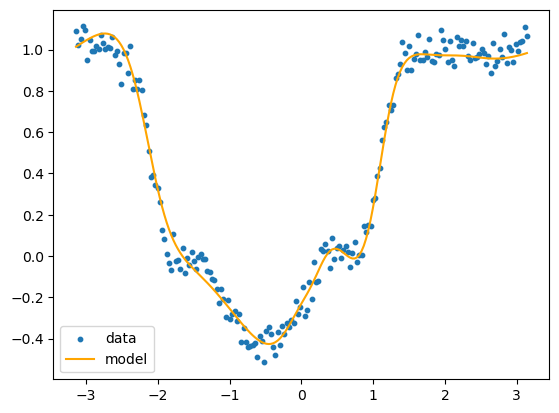

In [9]:
np.random.seed(0)
x = np.linspace(-np.pi, np.pi, 200)
y = (np.tanh(x**2 + x - 1))**5 + np.random.normal(0, 0.05, len(x))
X = x.reshape(-1, 1)

params = train(X, y, [1, 10, 10,10,10,10, 1], lr=0.01, iters=100000, activation="tanh")

y_pred, _ = forward(X, params)

plt.scatter(x, y, s=10, label="data")
plt.plot(x, y_pred, color="orange", label="model")
plt.legend(); plt.show()
